# Stroke Prediction Analytics – Sprint 3
## Advanced Statistics & Feature Engineering

**Goal:** Validate Sprint 2 findings using statistical techniques and engineer meaningful features.

Sprint 3 requirements: Statistical Analysis, Hypothesis Testing, Confidence Interval Analysis, Feature Engineering, Feature Evaluation, and Final Business Recommendations.

## 1. Import Required Libraries

The project brief requires Python, NumPy, Pandas, Matplotlib, Seaborn and SciPy.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, f_oneway

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


### Sprint 1 → Data Preparation
Sprint 1 focused on understanding, cleaning, validating, and preparing the stroke dataset for analysis. 
The cleaned dataset (`stroke_cleaned.csv`) created from Sprint 1 is used as the starting point for Sprint 3.

Important Sprint 1 preparation included:
- Handling missing BMI values using median imputation
- Checking duplicate records
- Validating data types and categorical values
- Checking invalid values and outliers
- Preparing an analysis-ready dataset

### Sprint 2 → Exploratory Data Analysis
Sprint 2 was used to identify important patterns and relationships in the cleaned dataset.

Key findings carried forward into Sprint 3:
- Stroke patients were considerably older on average than non-stroke patients.
- Average glucose level was higher among stroke patients.
- Age showed the clearest positive numerical association with stroke among the main numerical variables.
- BMI showed a relatively weak relationship with stroke.
- Differences in stroke rates were observed across smoking status, work type, and marital status.
- Group-based and multivariate analysis suggested that stroke occurrence should be examined using multiple patient characteristics rather than a single variable.

### Sprint 3 → Statistical Validation & Feature Engineering
Sprint 3 builds on these findings by:
1. Statistically testing important observations from Sprint 2.
2. Measuring confidence intervals for numerical variables.
3. Engineering meaningful features using findings from Sprint 1 and Sprint 2.
4. Evaluating whether the engineered features improve understanding of stroke risk patterns.
5. Converting the analytical findings into final business recommendations.

### Overall Workflow

**Sprint 1:** Clean & Validate Data  
↓  
**Sprint 2:** Explore Patterns & Relationships  
↓  
**Sprint 3:** Statistically Validate Findings  
↓  
**Feature Engineering:** Create Meaningful Patient Segments  
↓  
**Final:** Business Insights & Recommendations

## 2. Load the Dataset

The raw healthcare stroke dataset is loaded without manually modifying the source file.

In [35]:
file_path = "stroke_cleaned.csv"
df = pd.read_csv("stroke_cleaned.csv")

print("Dataset loaded from Sprint 1 cleaned dataset.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded from Sprint 1 cleaned dataset.
Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0000,0,1,Yes,Private,Urban,228.6900,36.6000,formerly smoked,1
1,51676,Female,61.0000,0,0,Yes,Self-employed,Rural,202.2100,28.1000,never smoked,1
2,31112,Male,80.0000,0,1,Yes,Private,Rural,105.9200,32.5000,never smoked,1
3,60182,Female,49.0000,0,0,Yes,Private,Urban,171.2300,34.4000,smokes,1
4,1665,Female,79.0000,1,0,Yes,Self-employed,Rural,174.1200,24.0000,never smoked,1


## 3. Initial Data Check

Check structure, missing values, duplicates and target values before analysis.

In [8]:
print("Data types:")
display(df.dtypes)
print("\nMissing values:")
display(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nStroke values:")
display(df["stroke"].value_counts())

Data types:


id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


Missing values:


id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


Duplicate rows: 0

Stroke values:


stroke
0    4861
1     249
Name: count, dtype: int64

## 4. BMI Missing-Value Handling

Sprint 1 handled missing BMI values using median imputation. The same approach is retained for consistency.

**Justification:** BMI is numerical and median imputation is less sensitive to extreme values than mean imputation.

In [9]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())
print("Missing BMI after imputation:", df["bmi"].isnull().sum())

Missing BMI after imputation: 0


# 5. Statistical Analysis

This section covers central tendency, dispersion, distribution analysis, correlation and covariance.

## 5.1 Measures of Central Tendency

In [10]:
numeric_cols = ["age", "avg_glucose_level", "bmi"]
central_tendency = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": [df[c].mode().iloc[0] for c in numeric_cols]
})
display(central_tendency)

,Mean,Median,Mode
age,43.2266,45.0000,78.0000
avg_glucose_level,106.1477,91.8850,93.8800
bmi,28.8620,28.1000,28.1000


### Interpretation
Mean, median and mode describe the center of each numerical distribution. Differences between mean and median can indicate skewness.

## 5.2 Measures of Dispersion

In [11]:
dispersion = pd.DataFrame({
    "Standard Deviation": df[numeric_cols].std(),
    "Variance": df[numeric_cols].var(),
    "Range": df[numeric_cols].max() - df[numeric_cols].min(),
    "IQR": df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
})
display(dispersion)

,Standard Deviation,Variance,Range,IQR
age,22.6126,511.3318,81.9200,36.0000
avg_glucose_level,45.2836,2050.6008,216.6200,36.8450
bmi,7.6996,59.2833,87.3000,9.0000


### Interpretation
Standard deviation, variance, range and IQR show how widely patient values are spread. Larger values indicate greater variation.

## 5.3 Distribution Analysis

In [12]:
distribution_stats = pd.DataFrame({
    "Skewness": df[numeric_cols].skew(),
    "Kurtosis": df[numeric_cols].kurt()
})
display(distribution_stats)

,Skewness,Kurtosis
age,-0.1371,-0.9910
avg_glucose_level,1.5723,1.6805
bmi,1.0882,3.6353


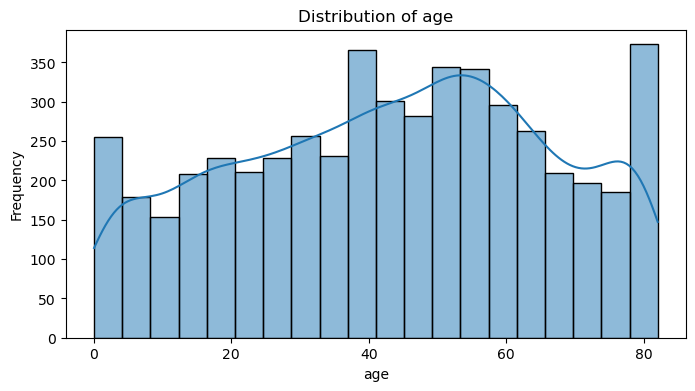

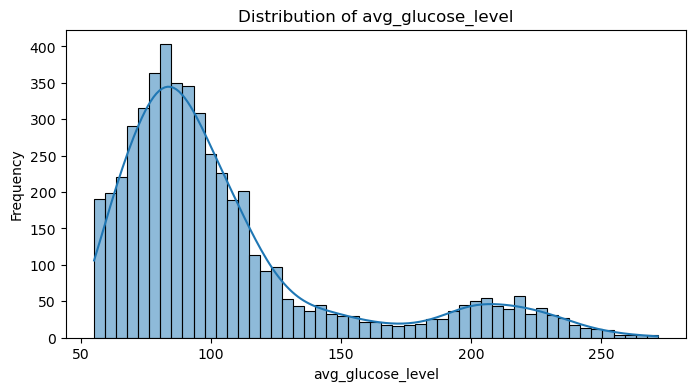

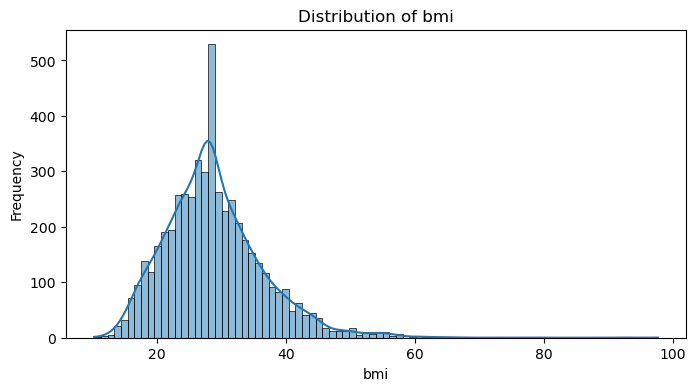

In [13]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Interpretation
Skewness measures asymmetry. Positive skewness indicates a longer right tail; negative skewness indicates a longer left tail. Kurtosis describes tail behavior relative to a normal distribution.

## 5.4 Correlation Analysis

In [14]:
corr_cols = ["age", "avg_glucose_level", "bmi", "stroke"]
correlation_matrix = df[corr_cols].corr()
display(correlation_matrix)

,age,avg_glucose_level,bmi,stroke
age,1.0000,0.2382,0.3243,0.2453
avg_glucose_level,0.2382,1.0000,0.1669,0.1319
bmi,0.3243,0.1669,1.0000,0.0361
stroke,0.2453,0.1319,0.0361,1.0000


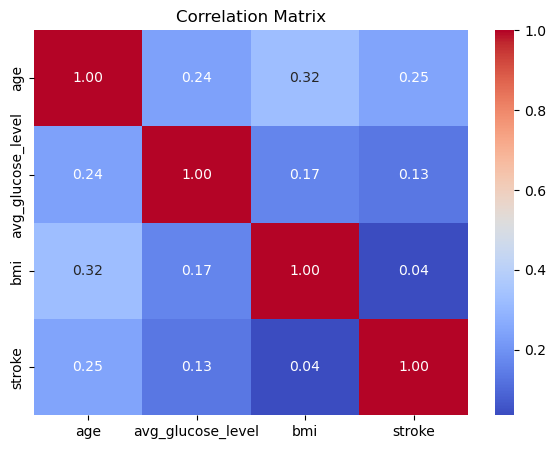

In [15]:
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Interpretation
Correlation ranges from -1 to +1. Positive values indicate variables tend to increase together and negative values indicate an inverse relationship. Correlation does not prove causation.

Sprint 2 found that age had the clearest positive association with stroke among the main numerical variables, while BMI had a much weaker association.

## 5.5 Covariance Analysis

In [16]:
covariance_matrix = df[corr_cols].cov()
display(covariance_matrix)

,age,avg_glucose_level,bmi,stroke
age,511.3318,243.8827,56.4623,1.1941
avg_glucose_level,243.8827,2050.6008,58.1835,1.2865
bmi,56.4623,58.1835,59.2833,0.0599
stroke,1.1941,1.2865,0.0599,0.0464


### Interpretation
Positive covariance means variables tend to move in the same direction and negative covariance means they tend to move in opposite directions. Covariance depends on measurement units, so correlation is easier to compare across variables.

## Sprint 2 Findings Being Statistically Validated

The hypothesis tests in this section are directly connected to observations identified during Sprint 2.

### Finding 1: Age and Stroke
Sprint 2 showed that patients with stroke had a much higher average age than patients without stroke.

**Sprint 3 validation:** Welch's independent t-test is used to determine whether the difference in average age between the two groups is statistically significant.

### Finding 2: Average Glucose Level and Stroke
Sprint 2 showed that the average glucose level was higher among patients with stroke.

**Sprint 3 validation:** Welch's independent t-test is used to test whether the difference in average glucose level between the two groups is statistically significant.

### Finding 3: Categorical Factors and Stroke
Sprint 2 identified differences in stroke rates across categorical variables such as gender and smoking status.

**Sprint 3 validation:** Chi-square tests are used to examine whether these categorical variables have a statistically significant association with stroke.

### Finding 4: Work Type and Age
Sprint 2 group-based analysis showed differences in average age across work types.

**Sprint 3 validation:** One-way ANOVA is used to test whether average age differs significantly across work-type groups.

These tests help distinguish patterns observed during EDA from relationships that have statistical evidence in the dataset.

# 6. Hypothesis Testing

**Significance level: α = 0.05**

Selected tests:
- Independent-samples Welch t-test for numerical variables
- Chi-square test for categorical variables
- One-way ANOVA for age across work types

Each test reports the hypotheses, statistic, p-value, decision and business interpretation.

In [17]:
alpha = 0.05
stroke_group = df[df["stroke"] == 1]
nonstroke_group = df[df["stroke"] == 0]
print("Stroke cases:", len(stroke_group))
print("Non-stroke cases:", len(nonstroke_group))

Stroke cases: 249
Non-stroke cases: 4861


## 6.1 T-Test: Age

**H₀:** Mean age is equal for stroke and non-stroke patients.

**H₁:** Mean age is different for stroke and non-stroke patients.

In [18]:
t_age, p_age = ttest_ind(stroke_group["age"], nonstroke_group["age"], equal_var=False)
print("T-statistic:", t_age)
print("p-value:", p_age)
print("Decision:", "Reject H0" if p_age < alpha else "Fail to reject H0")

T-statistic: 29.68626563006023
p-value: 2.115684848347272e-95
Decision: Reject H0


### Business Interpretation
This test checks whether the observed difference in mean age between stroke and non-stroke groups is statistically significant. A p-value below 0.05 provides evidence of a difference in group means.

## 6.2 T-Test: Average Glucose Level

**H₀:** Mean average glucose level is equal for stroke and non-stroke patients.

**H₁:** Mean average glucose level is different between the two groups.

In [19]:
t_glucose, p_glucose = ttest_ind(stroke_group["avg_glucose_level"], nonstroke_group["avg_glucose_level"], equal_var=False)
print("T-statistic:", t_glucose)
print("p-value:", p_glucose)
print("Decision:", "Reject H0" if p_glucose < alpha else "Fail to reject H0")

T-statistic: 6.982411744792963
p-value: 2.4014366563697676e-11
Decision: Reject H0


### Business Interpretation
This test evaluates whether the difference in average glucose between stroke and non-stroke groups is statistically significant.

## 6.3 Chi-Square Test: Gender vs Stroke

**H₀:** Gender and stroke occurrence are independent.

**H₁:** Gender and stroke occurrence are associated.

In [20]:
gender_table = pd.crosstab(df["gender"], df["stroke"])
chi_gender, p_gender, dof_gender, expected_gender = chi2_contingency(gender_table)
display(gender_table)
print("Chi-square statistic:", chi_gender)
print("p-value:", p_gender)
print("Decision:", "Reject H0" if p_gender < alpha else "Fail to reject H0")

stroke,0,1
gender,,
Female,2853,141
Male,2007,108
Other,1,0


Chi-square statistic: 0.47258662884530234
p-value: 0.7895490538408245
Decision: Fail to reject H0


### Business Interpretation
The chi-square test checks whether gender and stroke occurrence are statistically associated. Very small categories should be interpreted cautiously.

## 6.4 Chi-Square Test: Smoking Status vs Stroke

**H₀:** Smoking status and stroke occurrence are independent.

**H₁:** Smoking status and stroke occurrence are associated.

In [21]:
smoking_table = pd.crosstab(df["smoking_status"], df["stroke"])
chi_smoking, p_smoking, dof_smoking, expected_smoking = chi2_contingency(smoking_table)
display(smoking_table)
print("Chi-square statistic:", chi_smoking)
print("p-value:", p_smoking)
print("Decision:", "Reject H0" if p_smoking < alpha else "Fail to reject H0")

stroke,0,1
smoking_status,,
Unknown,1497,47
formerly smoked,815,70
never smoked,1802,90
smokes,747,42


Chi-square statistic: 29.147269191399264
p-value: 2.0853997025008455e-06
Decision: Reject H0


### Business Interpretation
The test evaluates whether stroke occurrence differs systematically across smoking-status categories. Statistical association does not establish causation.

## 6.5 One-Way ANOVA: Age Across Work Types

**H₀:** Mean age is the same across all work-type groups.

**H₁:** At least one work-type group has a different mean age.

In [22]:
work_groups = [group["age"].dropna().values for _, group in df.groupby("work_type")]
anova_stat, anova_p = f_oneway(*work_groups)
print("ANOVA F-statistic:", anova_stat)
print("p-value:", anova_p)
print("Decision:", "Reject H0" if anova_p < alpha else "Fail to reject H0")

ANOVA F-statistic: 1110.0850632053032
p-value: 0.0
Decision: Reject H0


### Business Interpretation
ANOVA checks whether average age differs across work-type groups. If significant, at least one group differs; ANOVA alone does not identify which groups differ.

# 7. Confidence Interval Analysis

Construct 95% confidence intervals for the population means of age, average glucose level and BMI.

In [23]:
def mean_confidence_interval(series, confidence=0.95):
    x = series.dropna()
    n = len(x)
    mean = x.mean()
    sem = stats.sem(x)
    margin = stats.t.ppf((1 + confidence) / 2, n - 1) * sem
    return mean, mean - margin, mean + margin

ci_results = []
for col in numeric_cols:
    mean, lower, upper = mean_confidence_interval(df[col])
    ci_results.append([col, mean, lower, upper])

ci_df = pd.DataFrame(ci_results, columns=["Variable", "Sample Mean", "95% CI Lower", "95% CI Upper"])
display(ci_df)

,Variable,Sample Mean,95% CI Lower,95% CI Upper
0,age,43.2266,42.6065,43.8468
1,avg_glucose_level,106.1477,104.9058,107.3896
2,bmi,28.8620,28.6509,29.0732


### Interpretation
A 95% confidence interval provides a range estimated for the population mean using the sample and the assumptions of the method.

# 8. Feature Engineering

The project brief gives examples such as Age Group, BMI Category, Risk Category, Health Score, Lifestyle Index and Combined Disease Indicator. Each feature below has a business purpose.

**Important:** the risk-related scores created here are project-specific analytical features, not clinical scores or diagnoses.

## Feature Engineering 

The engineered features below are based on the findings obtained during Sprint 1 and Sprint 2.

### 1. Age Group
**Why:** Sprint 2 showed a substantial difference in age between stroke and non-stroke patients, with age showing the clearest positive numerical association with stroke.

**Business purpose:** Grouping patients into age ranges makes age-related patterns easier to understand and supports patient segmentation.

### 2. BMI Category
**Why:** BMI was analyzed during Sprint 2. Although BMI showed a relatively weak direct relationship with stroke, BMI remains a useful health-related characteristic for patient segmentation.

**Business purpose:** Converting BMI into categories makes it easier to compare stroke patterns across weight ranges.

### 3. Combined Disease Indicator
**Why:** Hypertension and heart disease represent important patient health characteristics available in the dataset.

**Business purpose:** Combining these indicators provides a simple way to identify patients with one or more recorded cardiovascular-related conditions.

### 4. Health Score
**Why:** Sprint 2 showed that stroke patterns involve multiple patient characteristics rather than only one variable.

**Business purpose:** Combining selected health-related indicators creates an analytical score that can be used to segment patients according to the number of observed risk-related characteristics.

**Note:** This is a project-specific analytical feature and is not a clinical risk score or medical diagnosis.

### 5. Lifestyle Index
**Why:** Sprint 2 examined smoking status, work type, and residence type and identified differences in stroke rates across these groups.

**Business purpose:** Combining selected lifestyle-related characteristics provides another way to segment patients for business analysis.

**Note:** This is an analytical feature created for this project and should not be interpreted as a clinical measure.

### 6. Risk Category
**Why:** Sprint 2 showed that several variables were associated with different stroke patterns. Sprint 3 therefore combines selected age, health, glucose, BMI, and smoking indicators.

**Business purpose:** Converting the combined score into categories makes the results easier to communicate to healthcare management and supports patient-group analysis.

**Note:** The risk category is an analytical segmentation created for this project and is not a clinical prediction or diagnosis.

## 8.1 Age Group

In [24]:
df["age_group"] = pd.cut(df["age"], bins=[0, 18, 40, 60, 100], labels=["Child", "Young Adult", "Middle Age", "Older Adult"], include_lowest=True)
display(df[["age", "age_group"]].head())

,age,age_group
0,67.0000,Older Adult
1,61.0000,Older Adult
2,80.0000,Older Adult
3,49.0000,Middle Age
4,79.0000,Older Adult


**Business purpose:** Makes age easier to use for patient segmentation and reporting.

## 8.2 BMI Category

In [25]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[-np.inf, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])
display(df[["bmi", "bmi_category"]].head())

,bmi,bmi_category
0,36.6000,Obese
1,28.1000,Overweight
2,32.5000,Obese
3,34.4000,Obese
4,24.0000,Normal


**Business purpose:** Converts continuous BMI into understandable groups for comparison of patient patterns.

## 8.3 Combined Disease Indicator

In [26]:
df["combined_disease_indicator"] = df["hypertension"].astype(int) + df["heart_disease"].astype(int)
print(df["combined_disease_indicator"].value_counts().sort_index())

combined_disease_indicator
0    4400
1     646
2      64
Name: count, dtype: int64


**Business purpose:** Summarizes whether a patient has neither, one, or both recorded conditions.

## 8.4 Risk Category

In [27]:
df["risk_score"] = (
    (df["age"] >= 60).astype(int) * 2
    + df["hypertension"].astype(int)
    + df["heart_disease"].astype(int)
    + (df["avg_glucose_level"] >= 126).astype(int)
    + (df["bmi"] >= 30).astype(int)
    + df["smoking_status"].isin(["smokes", "formerly smoked"]).astype(int)
)

df["risk_category"] = pd.cut(df["risk_score"], bins=[-1, 1, 3, np.inf], labels=["Lower Risk", "Moderate Risk", "Higher Risk"])
display(df[["risk_score", "risk_category"]].head())

,risk_score,risk_category
0,6,Higher Risk
1,3,Moderate Risk
2,4,Higher Risk
3,3,Moderate Risk
4,4,Higher Risk


**Business purpose:** Combines several observed indicators into an easy-to-understand analytical grouping. This is not a validated clinical risk calculator.

## 8.5 Health Score

In [28]:
df["health_score"] = (
    df["hypertension"].astype(int)
    + df["heart_disease"].astype(int)
    + (df["avg_glucose_level"] >= 126).astype(int)
    + (df["bmi"] >= 30).astype(int)
    + (df["age"] >= 60).astype(int)
)
print(df["health_score"].value_counts().sort_index())

health_score
0    2031
1    1739
2     856
3     350
4     120
5      14
Name: count, dtype: int64


**Business purpose:** Counts selected health-related indicators to support simple patient segmentation.

## 8.6 Lifestyle Index

In [29]:
df["lifestyle_index"] = (
    df["smoking_status"].isin(["smokes", "formerly smoked"]).astype(int)
    + df["work_type"].isin(["Private", "Self-employed"]).astype(int)
    + (df["Residence_type"] == "Urban").astype(int)
)
print(df["lifestyle_index"].value_counts().sort_index())

lifestyle_index
0     540
1    1860
2    1976
3     734
Name: count, dtype: int64


**Business purpose:** Creates a simple project-specific grouping from selected lifestyle/context variables. It should not be interpreted as a medical measure.

# 9. Feature Evaluation

Evaluate whether the engineered features make stroke patterns easier to understand.

In [30]:
engineered_cols = ["age_group", "bmi_category", "combined_disease_indicator", "risk_score", "risk_category", "health_score", "lifestyle_index"]
feature_check = pd.DataFrame({
    "Unique Values": [df[c].nunique() for c in engineered_cols],
    "Missing Values": [df[c].isna().sum() for c in engineered_cols]
}, index=engineered_cols)
display(feature_check)

,Unique Values,Missing Values
age_group,4,0
bmi_category,4,0
combined_disease_indicator,3,0
risk_score,8,0
risk_category,3,0
health_score,6,0
lifestyle_index,4,0


## 9.1 Stroke Rate by Engineered Features

In [31]:
def stroke_rate_table(column):
    result = df.groupby(column, observed=True)["stroke"].agg(["count", "sum", "mean"])
    result["stroke_rate_percent"] = result["mean"] * 100
    return result.sort_values("stroke_rate_percent", ascending=False)

display(stroke_rate_table("age_group"))
display(stroke_rate_table("bmi_category"))
display(stroke_rate_table("risk_category"))
display(stroke_rate_table("health_score"))

,count,sum,mean,stroke_rate_percent
age_group,,,,
Older Adult,1304,177,0.1357,13.5736
Middle Age,1562,64,0.0410,4.0973
Young Adult,1328,6,0.0045,0.4518
Child,916,2,0.0022,0.2183


,count,sum,mean,stroke_rate_percent
bmi_category,,,,
Overweight,1610,115,0.0714,7.1429
Obese,1893,96,0.0507,5.0713
Normal,1258,37,0.0294,2.9412
Underweight,349,1,0.0029,0.2865


,count,sum,mean,stroke_rate_percent
risk_category,,,,
Higher Risk,648,98,0.1512,15.1235
Moderate Risk,1579,116,0.0735,7.3464
Lower Risk,2883,35,0.0121,1.2140


,count,sum,mean,stroke_rate_percent
health_score,,,,
5,14,4,0.2857,28.5714
4,120,23,0.1917,19.1667
3,350,55,0.1571,15.7143
2,856,71,0.0829,8.2944
1,1739,73,0.0420,4.1978
0,2031,23,0.0113,1.1324


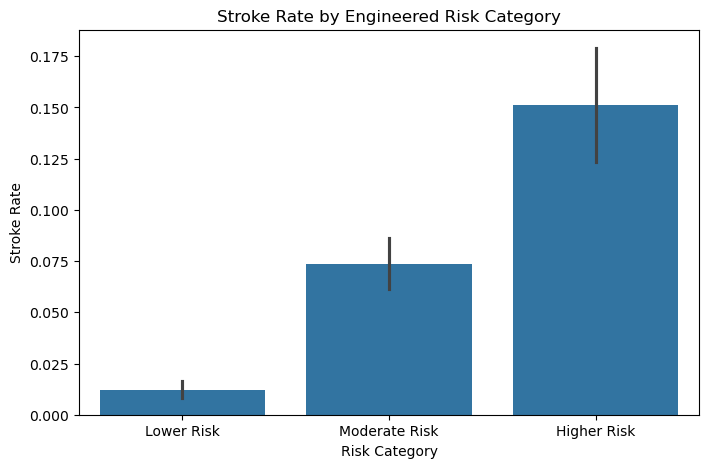

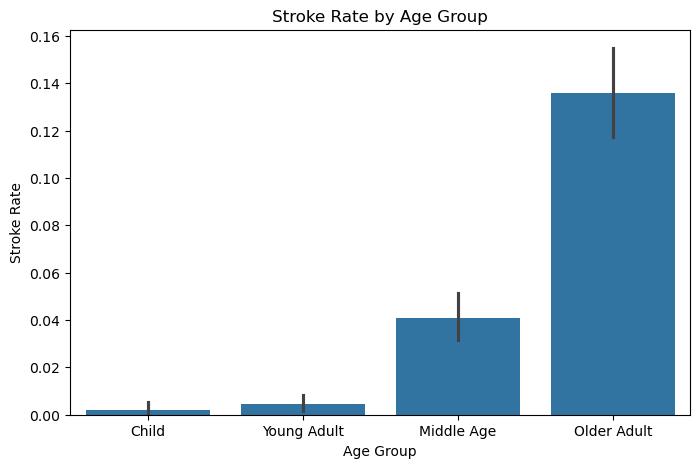

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="risk_category", y="stroke", estimator=np.mean)
plt.title("Stroke Rate by Engineered Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Stroke Rate")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="age_group", y="stroke", estimator=np.mean)
plt.title("Stroke Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Stroke Rate")
plt.show()

### Feature Evaluation Interpretation
The engineered features convert continuous variables and multiple indicators into clearer groups for reporting. Age Group and Risk Category support segmentation, while BMI Category, Health Score and Combined Disease Indicator provide additional summaries. These features improve data understanding but are not clinically validated prediction scores.

# 10. Final Statistical Summary

In [33]:
summary_table = pd.DataFrame({
    "Analysis": [
        "Age: Stroke vs Non-Stroke T-test",
        "Glucose: Stroke vs Non-Stroke T-test",
        "Gender vs Stroke Chi-square",
        "Smoking Status vs Stroke Chi-square",
        "Age across Work Types ANOVA"
    ],
    "Statistic": [t_age, t_glucose, chi_gender, chi_smoking, anova_stat],
    "p_value": [p_age, p_glucose, p_gender, p_smoking, anova_p],
    "Decision": [
        "Reject H0" if p_age < alpha else "Fail to reject H0",
        "Reject H0" if p_glucose < alpha else "Fail to reject H0",
        "Reject H0" if p_gender < alpha else "Fail to reject H0",
        "Reject H0" if p_smoking < alpha else "Fail to reject H0",
        "Reject H0" if anova_p < alpha else "Fail to reject H0"
    ]
})
display(summary_table)

,Analysis,Statistic,p_value,Decision
0,Age: Stroke vs Non-Stroke T-test,29.6863,0.0000,Reject H0
1,Glucose: Stroke vs Non-Stroke T-test,6.9824,0.0000,Reject H0
2,Gender vs Stroke Chi-square,0.4726,0.7895,Fail to reject H0
3,Smoking Status vs Stroke Chi-square,29.1473,0.0000,Reject H0
4,Age across Work Types ANOVA,1110.0851,0.0000,Reject H0


# 11. Final Business Recommendations

- Give greater analytical attention to older patient groups, consistent with the Sprint 2 findings.
- Monitor average glucose level together with other patient characteristics.
- Include smoking history, hypertension, heart disease and BMI in multi-factor analysis.
- Use engineered age and risk groups for clearer reporting and patient segmentation.
- Use Health Score and Combined Disease Indicator to summarize multiple recorded health indicators.
- Treat all engineered scores in this notebook as analytical features rather than clinical diagnoses.
- Use statistical significance together with practical context, sample size and category size when communicating findings.

## Overall Conclusion
Sprint 3 extends the earlier exploratory analysis by applying statistical tests, confidence intervals, covariance analysis and feature engineering. The results provide additional evidence for patterns observed in Sprint 2 and create structured features that can support further analysis or predictive-model development.

# 12. Final Validation

In [34]:
print("Final dataset shape:", df.shape)
print("\nEngineered columns:")
print(engineered_cols)
print("\nMissing values in engineered columns:")
display(df[engineered_cols].isnull().sum())
print("\nSprint 3 completed successfully.")

Final dataset shape: (5110, 19)

Engineered columns:
['age_group', 'bmi_category', 'combined_disease_indicator', 'risk_score', 'risk_category', 'health_score', 'lifestyle_index']

Missing values in engineered columns:


age_group                     0
bmi_category                  0
combined_disease_indicator    0
risk_score                    0
risk_category                 0
health_score                  0
lifestyle_index               0
dtype: int64


Sprint 3 completed successfully.
